<a href="https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatVTON basic front inference example

## Connect to Google Drive
It is convenient to load data from external source than manually drag it into colab env

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## CatVTON installation

In [14]:
# Клонируем репозиторий CatVTON
%cd /content
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 47.97 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [15]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-7qqmllpp
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-7qqmllpp
  Resolved https://github.com/huggingface/diffusers.git to commit e39aecff57ed14d1018529c3de6ec3c34fadb559
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (s

In [1]:
# Обновляем accelerate до последней версии (1.13.0) и ставим стабильный diffusers
!pip install -U accelerate==1.13.0 diffusers==0.30.3 peft huggingface_hub

  Using cached huggingface_hub-1.16.1-py3-none-any.whl.metadata (14 kB)


In [2]:
# Clean up existing conflicting installations first
!pip uninstall -y torch torchvision torchaudio xformers

Found existing installation: torch 2.5.0+cu124
Uninstalling torch-2.5.0+cu124:
  Successfully uninstalled torch-2.5.0+cu124
Found existing installation: torchvision 0.20.0+cu124
Uninstalling torchvision-0.20.0+cu124:
  Successfully uninstalled torchvision-0.20.0+cu124
Found existing installation: torchaudio 2.5.0+cu124
Uninstalling torchaudio-2.5.0+cu124:
  Successfully uninstalled torchaudio-2.5.0+cu124
Found existing installation: xformers 0.0.28.post2
Uninstalling xformers-0.0.28.post2:
  Successfully uninstalled xformers-0.0.28.post2


In [3]:
# Upgrade setuptools to provide the distutils shim required by Python 3.12
!pip install setuptools --upgrade

In [19]:
# Устанавливаем PyTorch 2.4.1 (CUDA 12.4) и совместимую с Python 3.12 версию xformers
# !pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124
# !pip install xformers==0.0.28.post1

In [4]:
# Upgrade xformers to a version >= 0.0.28.post2 to fix Python 3.12 type annotation errors.
# We must also upgrade torchvision to match the torch 2.5.0 requirement to prevent torchvision::nms CUDA errors.
!pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 xformers==0.0.28.post2 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.5.0%2Bcu124-cp312-cp312-linux_x86_64.whl (908.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.20.0%2Bcu124-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.5.0%2Bcu124-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached https://download.pytorch.org/whl/cu124/xformers-0.0.28.post2-cp312-cp312-manylinux_2_28_x86_64.whl (20.6 MB)


In [5]:
!nvcc --version

import torch
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
PyTorch version: 2.5.0+cu124
PyTorch CUDA version: 12.4


## Load sample garment and person

In [36]:
import urllib.request

# test human-model image (front view)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/person/men/model_5.png",
    "person.png"
)

# test garment image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/condition/upper/24083449_54173465_2048.jpg",
    "garment.jpg"
)

('garment.jpg', <http.client.HTTPMessage at 0x7de1d6c0fd70>)

## CatVTON imports

In [20]:
%cd /content/CatVTON

/content/CatVTON


In [21]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

## Initializing CatVTON models

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [24]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

mix-48k-1024/attention/model.safetensors:   0%|          | 0.00/198M [00:00<?, ?B/s]

Base-DensePose-RCNN-FPN.yaml: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

vitonhd-16k-512/attention/model.safetens(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [25]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


## Utility functions

In [26]:
def show_try_on_res(person, mask, try_on_result):
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(person)
    axs[0].set_title("Front Result (Reference)")
    axs[0].axis('off')

    axs[1].imshow(mask)
    axs[1].set_title("Try-On Mask")
    axs[1].axis('off')

    axs[2].imshow(try_on_result.resize(target_size))
    axs[2].set_title("Try-On Result")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [27]:
def show_multiple_images(images):
    n_images = len(images)
    fig, axs = plt.subplots(1, n_images, figsize=(5 * n_images, 6))

    if n_images == 1:
        axs.imshow(images[0])
        axs.axis('off')
    else:
        for i in range(n_images):
            axs[i].imshow(images[i])
            axs[i].axis('off')

    plt.tight_layout()
    plt.show()

In [28]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

def remove_background_from_all_in_dir(target_dir: Path, automasker):
    for file_path in target_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            img_pil = Image.open(file_path).convert("RGB")

            # Use automasker to get human parsing
            res = automasker(img_pil)

            # schp_atr contains class 0 for background, >0 for human/clothes/etc.
            schp_atr = np.array(res['schp_atr'])

            # Create a binary mask (255 for human, 0 for background)
            mask = (schp_atr > 0).astype(np.uint8) * 255

            # Optional: Smooth the mask slightly to avoid harsh jagged edges
            kernel = np.ones((3, 3), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

            # Convert img to cv2 format (RGB -> BGR for saving)
            img_cv2 = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

            # Apply mask (sets background to pure black)
            img_bg_removed = cv2.bitwise_and(img_cv2, img_cv2, mask=mask)

            # Overwrite the original image in the folder so 3DGS uses the masked version
            cv2.imwrite(str(file_path), img_bg_removed)

## Copy files from drive

In [35]:
!mkdir /content/clothes
!cp -r /content/drive/MyDrive/weavella/images/cloth_from_zoolando_website /content/clothes

## Example inference on front view

In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [ ]:
# 1. Load images
person_path = "/content/person.png"
# garment_path = "/content/garment.jpg"
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# On person
garment_path = garment_folder + "/6d51a17dfd0343a5a27b5971c92bfae9.webp"
garment_path = garment_folder + "/c4894c7140ca48f6af9b8cd05c2adc25.webp"
garment_path = garment_folder + "/9cbddc78aa24472e87bdec578049891c.webp"
garment_path = garment_folder + "/833fd6835df54ece81b53c66de90dd48.webp"
# pure flat-out t-shirt image
garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
garment_path = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

person_image = Image.open(person_path).convert("RGB")
garment_image = Image.open(garment_path).convert("RGB")

# size of the images for CatVTON
target_size = (768, 1024)
person_image = person_image.resize(target_size)
garment_image = garment_image.resize(target_size)

In [ ]:
# 1. Clear memory before running
torch.cuda.empty_cache()
gc.collect()

# 2. Generate mask
print("Generating mask...")
mask_result = automasker(person_image)
mask = mask_result['mask']

# 3. Run inference

print("Running inference (try-on). This may take a couple of minutes...")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

result_image = pipeline(
    image=person_image,
    condition_image=garment_image,
    mask=mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

Generating mask...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Running inference (try-on). This may take a couple of minutes...


100%|██████████| 50/50 [00:25<00:00,  1.97it/s]


In [ ]:
show_multiple_images((person_image, garment_image, mask, result_image))

# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

## Defining custon Reference Attention Processor

In [29]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        self.is_reference_pass = True
        self.bank_k = []
        self.bank_v = []
        self.step_idx = 0
        self.injection_steps = range(5, 45)

    def clear_bank(self):
        self.bank_k.clear()
        self.bank_v.clear()
        self.step_idx = 0

    def reset_read_index(self):
        self.step_idx = 0

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        batch_size, sequence_length, _ = hidden_states.shape

        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        # Transform dimensions to 4D for Flash Attention: (batch, heads, seq_len, head_dim)
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if self.is_reference_pass:
            # ОФФЛОАД НА CPU: сохраняем K и V в оперативную память
            self.bank_k.append(key.clone().detach().cpu())
            self.bank_v.append(value.clone().detach().cpu())
        else:
            # Извлекаем K и V строго для СООТВЕТСТВУЮЩЕГО шага
            if self.step_idx in self.injection_steps and self.step_idx < len(self.bank_k):
                # ВОЗВРАТ НА GPU: переносим нужный тензор обратно в память видеокарты
                ref_k = self.bank_k[self.step_idx].to(key.device)
                ref_v = self.bank_v[self.step_idx].to(value.device)

                # Handle batch mismatch (due to Classifier-Free Guidance)
                if key.shape[0] != ref_k.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)

                # Concatenate along the spatial dimension (dim=2 in 4D tensor)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

            self.step_idx += 1

        # 3. Memory-efficient Attention computation (SDPA)
        # Using 4D tensors enables memory-efficient / Flash Attention in PyTorch
        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False
                )
            except RuntimeError:
                # Fallback to math if necessary
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True, enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False
                    )

        # Reshape back to expected format
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---
# 2. Replace standard attention layers in U-Net with our custom one ONLY for up_blocks!
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    # Инициализируем наш кастомный процессор только для attn1 в up_blocks
    if "attn1" in name and "up_blocks" in name:
        print(f"replaced attn_processors[{name}] = {pipeline.unet.attn_processors.get(name, None)} with custom attention processor")
        attn_processors[name] = ReferenceAttentionProcessor()
    else:
        # Для всех остальных слоев (включая down_blocks и mid_block) оставляем дефолтные оптимизированные процессоры
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)


replaced attn_processors[up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.3.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn

## Testing Reference-Driven Editing (View Consistency)

For this test, we use `person.png` as the front view (reference) and a new image `person_side.png` as the side view.
*Please make sure you have uploaded `person_side.png` to Colab before running the code below.*

In [30]:
# Image paths in Tim's google drive
person_folder = "/content/drive/MyDrive/weavella/images/Photos_Manual_Selection/1"

front_person_path = person_folder + "/IMG_6508.JPG"
# side_person_path  = person_folder + "/IMG_6518.JPG"
side_person_path  = person_folder + "/IMG_6529.JPG"

# Load, rotate 90 degrees, and resize
target_size = (512, 768)
front_person_img = Image.open(front_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)
side_person_img = Image.open(side_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)


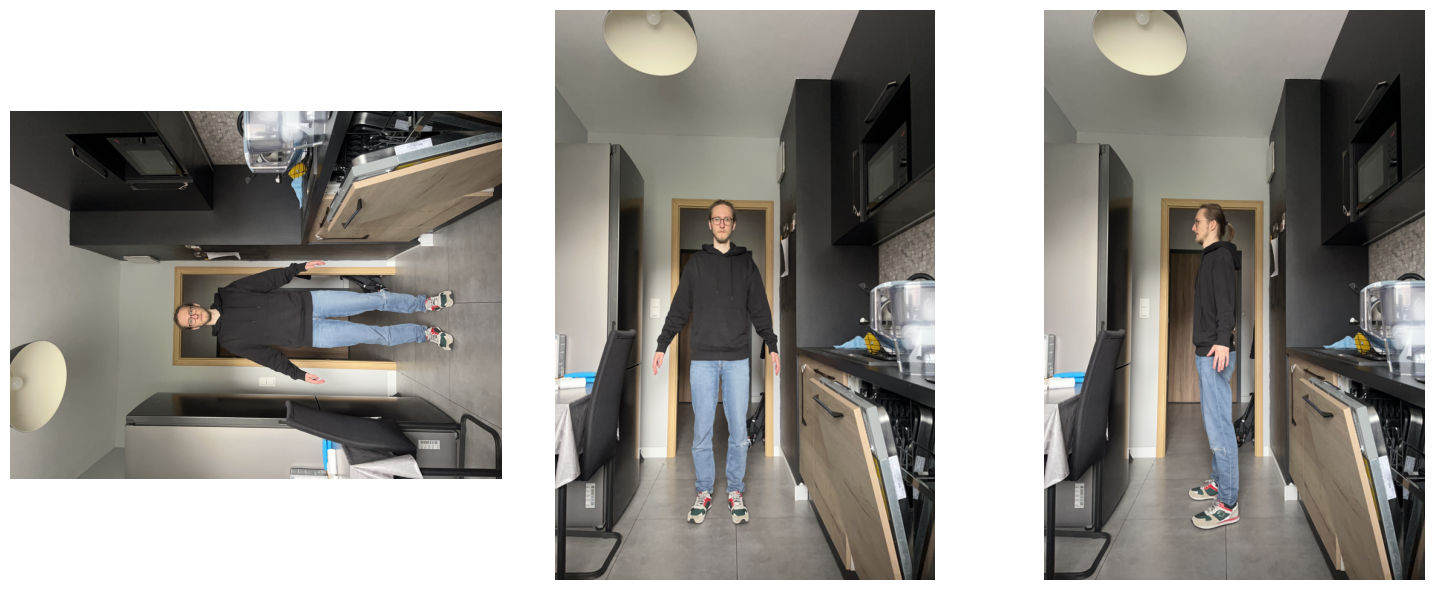

In [31]:
show_multiple_images((Image.open(front_person_path).convert("RGB"), front_person_img, side_person_img))

In [32]:
# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

print("Generating mask for side view...")
side_mask = automasker(side_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("\n--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

print("\n--- PASS 2: Target View Generation (Side) ---")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

# Tell processor to use saved features
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = False
        proc.reset_read_index()

side_result = pipeline(
    image=side_person_img,
    condition_image=garment_image,
    mask=side_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

Generating mask for front view...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Generating mask for side view...

--- PASS 1: Reference Generation (Front) ---


NameError: name 'garment_image' is not defined

In [ ]:
show_multiple_images((front_result, side_mask, side_result))

# Complete pipeline test on vadim video

## Install camenduru 3DGS (3DGS version for colab)

In [2]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 23.54 MiB/s, done.
Resolving deltas: 100% (346/346), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 171), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [3]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [4]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.5/819.5 kB 12.4 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [5]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

  Preparing metadata (setup.py) ... done


In [6]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [7]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

/content/gaussian-splatting
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3550102 sha256=da0ad3cae4460342f61fa748ad071585d954d8620255c210cd5553358f261f70
  Stored in directory: /root/.cache/pip/wheels/0a/f2/1b/255828ebad94ea248378281b7926639d83ce4f394f0052800d
Successfully built simple_knn


## Split video into images

In [8]:
!mkdir -p /content/gaussian-splatting/input/vadim
!cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/

In [9]:
!mkdir -p /content/gaussian-splatting/input/vadim/init_frames
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/init_frames/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# Copy video frames folder to Google Drive
# !cp -r /content/gaussian-splatting/input/vadim/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9

## Use CatVTON to try-on cloth on user from different angles

In [33]:
target_size = (768, 1024)

In [37]:
# different front-back
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
back_garment_path  = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)

In [38]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zoolando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"

# front_garment_path = garment_folder + "/e8cb036024b94af8aaeb5b8d38dfcb7c.webp" # pure flat-out t-shirt image
front_garment_path = garment_folder + "/e3c8055f31754cbbbeff96938543fdc1.webp" # on person
# back_garment_path  = garment_folder + "/95c143c6284549e99409498bf1b92679.webp" # pure flat-out t-shirt image
back_garment_path  = garment_folder + "/0c220ec6788a456194fa5184802d1743.webp" # on person
side_garment_path  = garment_folder + "/c172d2683ba54fe299fdbc6b5023658d.webp" # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [39]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"

front_person_path = person_folder + "/0012.jpg"
back_person_path  = person_folder + "/0041.jpg"

# Load and resize
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
back_person_img  = Image.open(back_person_path).convert("RGB").resize(target_size)

## Funcs to determine body position/rotation

### Custom mask generators

In [40]:
def naive_schp_refine_mask(coarse_result, dilate_size=1, dilate_iter=5):
    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract both SCHP lip and SCHP atr maps
    schp_lip = np.array(fine_mask_result['schp_lip'])
    schp_atr = np.array(fine_mask_result['schp_atr'])

    upper_clothes_mask = (schp_atr == 4).astype(np.uint8) * 255

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(upper_clothes_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")
    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [41]:
def schp_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract both SCHP lip and SCHP atr maps
    schp_lip = np.array(fine_mask_result['schp_lip'])
    schp_atr = np.array(fine_mask_result['schp_atr'])

    # Extract Upper-clothes from both models (LIP index 5, ATR index 4)
    lip_upper = (schp_lip == 5).astype(np.uint8) * 255
    atr_upper = (schp_atr == 4).astype(np.uint8) * 255

    # Evaluate which mask is "better" (heuristic: largest area)
    # This avoids compounding false positives while effectively avoiding the mask with a huge hole.
    lip_area = np.sum(lip_upper > 0)
    atr_area = np.sum(atr_upper > 0)

    if lip_area > atr_area:
        print(f"  -> Selecting LIP upper-clothes mask (larger area: {lip_area} vs {atr_area})")
        upper_clothes_mask = lip_upper
    else:
        print(f"  -> Selecting ATR upper-clothes mask (larger area: {atr_area} vs {lip_area})")
        upper_clothes_mask = atr_upper

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise in the background)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes (like the ear-sized hole) using Contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays" or boundary holes
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")
    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [ ]:
# Install transformers if it's not already installed
!pip install -q transformers

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

def segformer_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement (SegFormer) ---
    print("Phase 2: Refining Mask from Coarse Result using SegFormer...")

    # Run SegFormer on the coarse result image
    inputs = processor(images=coarse_result, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu()
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=coarse_result.size[::-1], # (W, H) -> (H, W)
        mode="bilinear",
        align_corners=False,
    )
    pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

    # Segformer B2 Clothes Upper-clothes class is 4
    upper_clothes_mask = (pred_seg == 4).astype(np.uint8) * 255

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes using Contours (Less necessary for SegFormer, but good for safety)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays"
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair, Scarves) ---
    # SegFormer Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(pred_seg, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

### 2 phase try-on:
1. low number of steps for try-on with big garment-agnostic mask
2. generate tight mask basing on coare try-on result from step 1
3. use tight mask with normal number of steps to produce final try-on

In [42]:
def two_phase_tryon(person_img, garment_img, automasker, pipeline, mask_refiner_fun, is_ref_pass=True, coarse_steps=50, fine_steps=50, seed=42):
    # --- Phase 1: Coarse Try-On ---
    print("Phase 1: Generating Coarse Mask and Try-On...")
    coarse_mask_result = automasker(person_img)
    coarse_mask = coarse_mask_result['mask']

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    generator = torch.Generator(device=device).manual_seed(seed)
    coarse_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=coarse_mask,
        num_inference_steps=coarse_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    refined_mask, masks_inbetween = mask_refiner_fun(coarse_result)

    # --- Phase 3: Final Fine Try-On ---
    print("Phase 3: Final High-Res Try-On with Refined Mask...")

    generator = torch.Generator(device=device).manual_seed(seed)

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    final_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=refined_mask,
        num_inference_steps=fine_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # Return all intermediate masks and final results
    return coarse_result, refined_mask, final_result, masks_inbetween

Phase 1: Generating Coarse Mask and Try-On...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:34<00:00,  1.46it/s]


Phase 2: Refining Mask from Coarse Result using SegFormer...
Phase 3: Final High-Res Try-On with Refined Mask...


100%|██████████| 50/50 [00:33<00:00,  1.51it/s]


Results: Original | Coarse Try-On | Refined Mask | Final Try-On


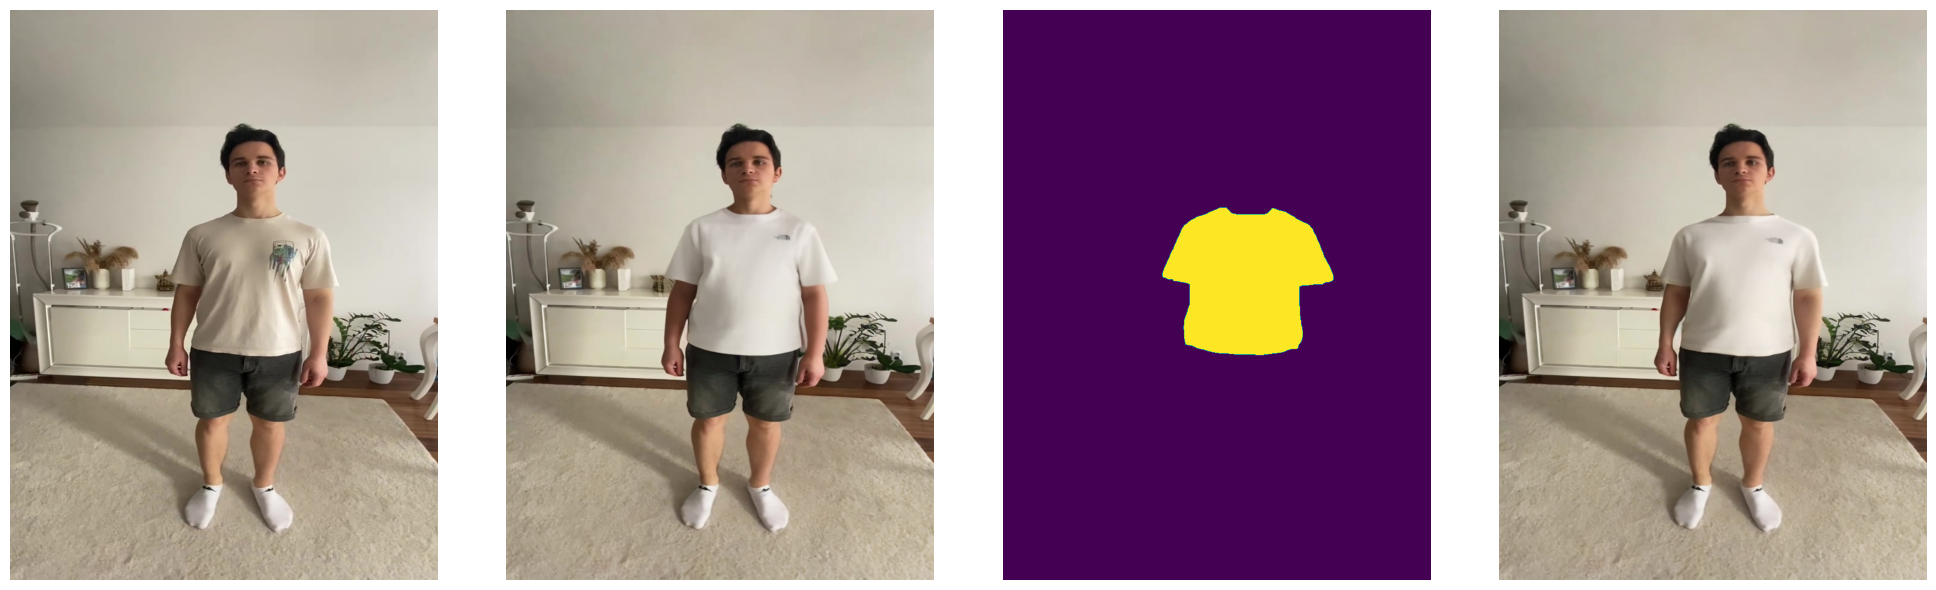

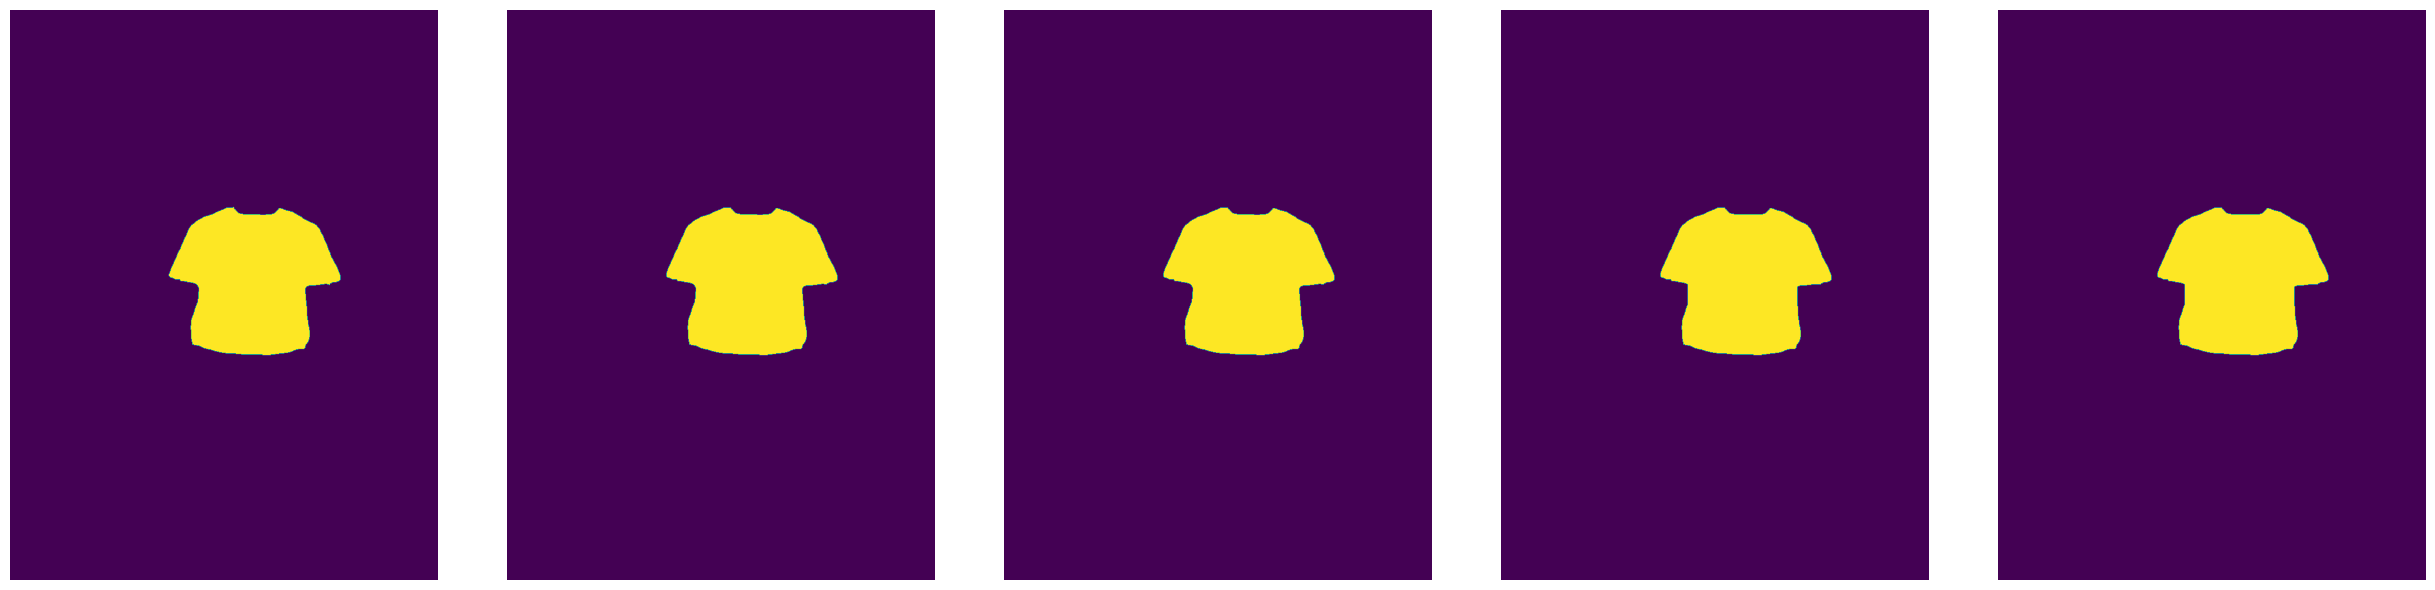

In [ ]:
# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    front_person_img,
    front_garment_image,
    automasker,
    pipeline,
    segformer_refine_mask # schp_refine_mask
)

# Show results
print("Results: Original | Coarse Try-On | Refined Mask | Final Try-On")
show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

DensePose parts and their pixel counts for the front view:
Part 2: 48733 pixels
Part 3: 2024 pixels
Part 4: 2774 pixels
Part 5: 3852 pixels
Part 6: 3943 pixels
Part 9: 7825 pixels
Part 10: 8242 pixels
Part 13: 5594 pixels
Part 14: 5931 pixels
Part 15: 3794 pixels
Part 16: 3632 pixels
Part 17: 1854 pixels
Part 18: 1457 pixels
Part 19: 1749 pixels
Part 20: 1707 pixels
Part 21: 3127 pixels
Part 22: 2007 pixels
Part 23: 5617 pixels
Part 24: 6607 pixels


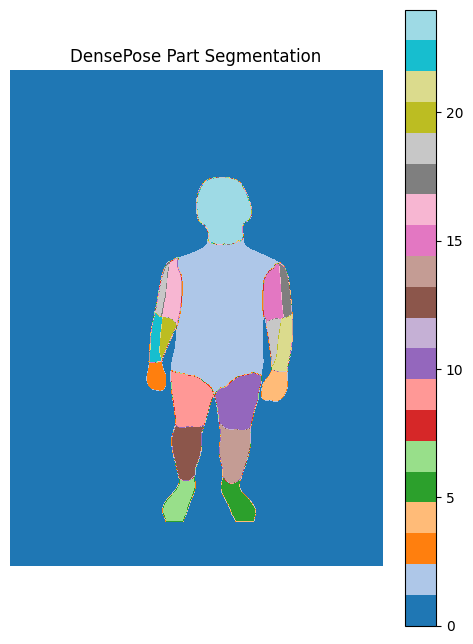

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The mask_result from automasker contains 'densepose' along with 'mask'
# Let's run automasker on the front image to inspect it
automasker_res = automasker(front_person_img)
densepose_img = np.array(automasker_res['densepose'])

# Find unique part indices and their pixel counts
unique_parts, counts = np.unique(densepose_img, return_counts=True)
print("DensePose parts and their pixel counts for the front view:")
for part, count in zip(unique_parts, counts):
    # 0 is usually background
    if part != 0:
        print(f"Part {part}: {count} pixels")

# Visualize the DensePose map
plt.figure(figsize=(6, 8))
plt.imshow(densepose_img, cmap='tab20')
plt.title("DensePose Part Segmentation")
plt.colorbar()
plt.axis('off')
plt.show()

# By observing which part index has the most pixels in the torso area for front vs back views,
# we can create a simple heuristic to determine the angle!

In [43]:
def determine_view_angle(densepose_img):
    """
    Determines if the person is facing front, back, or side based on DensePose segmentation.
    Part 1: Torso Back
    Part 2: Torso Front
    """
    densepose_array = np.array(densepose_img)

    front_torso_pixels = np.sum(densepose_array == 2)
    back_torso_pixels = np.sum(densepose_array == 1)

    total_torso = front_torso_pixels + back_torso_pixels

    if total_torso == 0:
        return "unknown"

    # Simple heuristic to determine the angle
    if front_torso_pixels > back_torso_pixels * 2:
        return "front"
    elif back_torso_pixels > front_torso_pixels * 2:
        return "back"
    else:
        return "side"

In [44]:
# Body rotation angle calculation. Super incorrect now because using raw pixels as measurement,
# should use more of a metric solution/some abstract sizing)

import cv2
import math
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

# 1. Initialize Detectron2 Keypoint Model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set threshold for this model
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.DEVICE = device
pose_predictor = DefaultPredictor(cfg)

# 2. Function to extract shoulder width and keypoints
def get_shoulder_width_and_kpts(img_pil):
    # Convert PIL RGB to OpenCV BGR
    img_bgr = np.array(img_pil)[:, :, ::-1]
    outputs = pose_predictor(img_bgr)

    if len(outputs["instances"]) == 0:
        return None, None

    # Get keypoints for the first detected person
    # COCO format: 5 is Left Shoulder, 6 is Right Shoulder.
    # Array shape: [17, 3] where 3 is (x, y, raw_score/logits)
    keypoints = outputs["instances"].pred_keypoints[0].cpu().numpy()

    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # Lowered threshold since these are raw logits, and even visible shoulders might score slightly > 0
    if l_shoulder[2] > 0.01 and r_shoulder[2] > 0.01:
        # 2D Euclidean distance (accounts for tilt/lean)
        width = math.hypot(l_shoulder[0] - r_shoulder[0], l_shoulder[1] - r_shoulder[1])
        return width, keypoints
    return None, keypoints

# 3. Test on the front image to establish our baseline (0 degrees)
front_width, front_kpts = get_shoulder_width_and_kpts(front_person_img)

if front_width is not None:
    print(f"Baseline Front Shoulder Width: {front_width:.2f} pixels")
else:
    print("Could not detect both shoulders with sufficient confidence.")

def calculate_angle_based_on_shoulder_width(current_width, max_width):
    if current_width is None or max_width is None or max_width == 0:
        return None
    # Clamp ratio between -1.0 and 1.0 to avoid math domain errors due to slight variations
    ratio = max(min(current_width / max_width, 1.0), -1.0)
    angle_rad = math.acos(ratio)
    angle_deg = math.degrees(angle_rad)
    return angle_deg

# Example of how it calculates 0 degrees for the exact same width
if front_width is not None:
    angle = calculate_angle_based_on_shoulder_width(front_width, front_width)
    print(f"Estimated Angle for front image: {angle:.1f} degrees")

AttributeError: module 'pkgutil' has no attribute 'ImpImporter'

## Determine body positions per frame

In [ ]:
# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

In [ ]:
body_params = {}
for file_path in all_files:
    print(f"processing {file_path}")
    person_img = Image.open(file_path).convert("RGB")

    automasker_res = automasker(person_img)
    densepose_img = np.array(automasker_res['densepose'])

    body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}
    # calculate angle
    # shoulder_width, front_kpts = get_shoulder_width_and_kpts(person_img)
    # body_params[file_path]['shoulder_width'] = shoulder_width

processing /content/gaussian-splatting/input/vadim/init_frames/0006.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0053.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0047.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0018.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0002.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0030.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0032.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0031.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0038.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0044.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0045.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0029.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0005.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0

## Front/Back split Try-on per frame

In [ ]:
front_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(front_person_path)
                         and body_params[f]['view_type'] == 'front'
                       ],
                      key=os.path.basename)
back_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'back'
                       ],
                      key=os.path.basename)
side_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'side'
                       ],
                      key=os.path.basename)

In [ ]:
front_images_try_on_targets = front_images[::5]
back_images_try_on_targets = back_images[::5]

In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [ ]:
output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

### side try-on

In [ ]:
for person_path in side_images:
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        side_garment_image,
        automasker,
        pipeline,
        # naive_schp_refine_mask, # often bad results
        schp_refine_mask,
        # segformer_refine_mask,
        is_ref_pass=True
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### front try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Front) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    front_person_img,
    front_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(front_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in front_images: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        front_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### back try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Back) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    back_person_img,
    back_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(back_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in back_images: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        back_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

## The same Try-on reference image for all images from all angles  

In [ ]:
# Sort the list of side person paths by filename
side_person_paths = sorted([f for f in all_files if os.path.abspath(f) != os.path.abspath(front_person_path)],
                           key=os.path.basename)

In [ ]:
side_images_try_on_targets = side_person_paths[::10]
side_images_try_on_targets

In [ ]:
import os


output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(front_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved front result to: {front_output_path}")

In [ ]:
show_try_on_res(front_person_img, front_mask, front_result)

In [ ]:
for side_person_path in side_images_try_on_targets: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

## Copy try-on results folder to Google Drive

In [ ]:
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/with_two_phase_mask/

## Run 3DGS training

### Install GPU-accelerated COLMAP

In [10]:
# All of these is to use GPU-accelerated version of COLMAP

# Install xvfb for OpenGL virtual display and required dependencies to build COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb cmake ninja-build \
    libboost-program-options-dev libboost-filesystem-dev libboost-graph-dev \
    libboost-system-dev libboost-test-dev libsuitesparse-dev \
    libfreeimage-dev libgoogle-glog-dev libgflags-dev \
    libglew-dev libqt5opengl5-dev qt5-qmake qtbase5-dev libceres-dev \
    libflann-dev libcgal-dev libmetis-dev

# Build COLMAP from source for GPU (CUDA) support
!rm -rf /content/colmap
!git clone --branch 3.9 https://github.com/colmap/colmap.git /content/colmap
%cd /content/colmap
!mkdir build
%cd build
!cmake .. -GNinja -DCUDA_ENABLED=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=native
!ninja
!sudo ninja install

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [86.4 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,355 kB]
Get:13 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2

### Create 3DGS model of vanila vadim

#### Run COLMAP

In [ ]:
# !rm -rf /content/gaussian-splatting/input/vadim/vanilla

In [11]:
!mkdir -p /content/gaussian-splatting/input/vadim/vanilla/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/vanilla/input/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [12]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/vanilla

/content/gaussian-splatting
I0525 12:25:36.944895  9131 misc.cc:198] 
Feature extraction
I0525 12:25:37.230500  9141 feature_extraction.cc:254] Processed file [1/58]
I0525 12:25:37.230548  9141 feature_extraction.cc:257]   Name:            0001.jpg
I0525 12:25:37.230552  9141 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0525 12:25:37.230556  9141 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0525 12:25:37.230573  9141 feature_extraction.cc:289]   Focal Length:    1536.00px
I0525 12:25:37.230585  9141 feature_extraction.cc:302]   Features:        4315
I0525 12:25:37.265372  9141 feature_extraction.cc:254] Processed file [2/58]
I0525 12:25:37.265420  9141 feature_extraction.cc:257]   Name:            0002.jpg
I0525 12:25:37.265424  9141 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0525 12:25:37.265427  9141 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0525 12:25:37.265432  9141 feature_extraction.cc:289]   Focal Length:    1536.00px
I0

In [13]:
# Save COLMAP results data to Google Drive
!mkdir -p /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_COLMAP_2fps_with_bg
!cp -r /content/gaussian-splatting/input/vadim/vanilla/* \
       /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_COLMAP_2fps_with_bg/

#### Determine body rotation angles from COLMAP

In [6]:
import os
import math
import json
import shutil
import struct
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

# Diffusers & PEFT
from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [18]:
# ---------------------------------------------------------------------------
# 1. COLMAP Parsing Utilities
# ---------------------------------------------------------------------------
def qvec2rotmat(qvec):
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]
    ])

def read_images_binary(path_to_model_file):
    """
    Reads the COLMAP images.bin file.
    Returns a dict mapping image_id to image info including name and Q, T.
    """
    images = {}
    with open(path_to_model_file, "rb") as fid:
        num_reg_images = struct.unpack("<Q", fid.read(8))[0]
        for _ in range(num_reg_images):
            binary_image_properties = struct.unpack("<idddddddi", fid.read(64))
            image_id = binary_image_properties[0]
            qvec = np.array(binary_image_properties[1:5])
            tvec = np.array(binary_image_properties[5:8])
            camera_id = binary_image_properties[8]
            image_name = ""
            current_char = struct.unpack("<c", fid.read(1))[0]
            while current_char != b"\x00":   # look for the null \0
                image_name += current_char.decode("utf-8")
                current_char = struct.unpack("<c", fid.read(1))[0]
            num_points2D = struct.unpack("<Q", fid.read(8))[0]
            # Skip 2D points (x, y, point3D_id) = 8 bytes + 8 bytes + 8 bytes = 24 bytes
            fid.seek(num_points2D * 24, 1)

            images[image_id] = {
                "name": image_name,
                "qvec": qvec,
                "tvec": tvec
            }
    return images

def calculate_azimuth(qvec, tvec, centroid=None):
    """
    Calculate the azimuthal angle (in degrees) of the camera relative to the origin.
    If centroid is provided, assumes the subject is centered at the given centroid.
    Camera center C = -R^T * T
    """
    R = qvec2rotmat(qvec)
    C = -np.dot(R.T, tvec)

    if centroid is not None:
        C = C - centroid

    # In COLMAP, standard coordinate system often has Y pointing down, Z forward.
    # The XZ plane is usually the ground plane.
    # Let's compute angle using atan2(x, z). Adjust this mapping if your world orientation differs.
    x, y, z = C
    angle_rad = math.atan2(x, z)
    angle_deg = math.degrees(angle_rad)

    # Normalize to 0-360
    if angle_deg < 0:
        angle_deg += 360
    return angle_deg

# ---------------------------------------------------------------------------
# 2. Dataset Partitioning
# ---------------------------------------------------------------------------
def partition_dataset(colmap_images_bin, source_image_dir, output_dir, anchor_image_name=None):
    """
    Partitions images into Front, Side, and Back folders based on camera azimuth.
    Optionally shifts angles to make anchor_image_name the 0-degree mark.
    """
    print("--- Partitioning Dataset based on COLMAP Azimuths ---")
    images_info = read_images_binary(colmap_images_bin)

    # Calculate centroid of all cameras
    centers = []
    for info in images_info.values():
        R = qvec2rotmat(info["qvec"])
        C = -np.dot(R.T, info["tvec"])
        centers.append(C)
    centroid = np.mean(centers, axis=0)
    print(f"Calculated camera centroid (new origin): {centroid}")

    # Calculate raw angles
    raw_angles = {}
    for img_id, info in images_info.items():
        raw_angles[info["name"]] = calculate_azimuth(info["qvec"], info["tvec"], centroid)

    # Determine angle shift to apply
    shift_angle = 0
    if anchor_image_name and anchor_image_name in raw_angles:
        shift_angle = raw_angles[anchor_image_name]
        print(f"Anchoring front to {anchor_image_name} (Raw Angle: {shift_angle:.2f} deg). Shifting all angles by -{shift_angle:.2f} deg.")

    partitions = {
        "front": [],
        "side": [],
        "back": []
    }

    angles = {}

    os.makedirs(os.path.join(output_dir, "front"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "side"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "back"), exist_ok=True)

    for img_id, info in images_info.items():
        name = info["name"]
        angle = (raw_angles[name] - shift_angle) % 360
        angles[name] = angle

        # Splatting the Cat partitions:
        # Front: -60 to 60 (or 300 to 360 and 0 to 60)
        # Back: 120 to 240
        # Side: 60 to 120, and 240 to 300

        if angle <= 60 or angle >= 300:
            category = "front"
        elif 120 <= angle <= 240:
            category = "back"
        else:
            category = "side"

        partitions[category].append(name)

        # Copy file
        src_path = os.path.join(source_image_dir, name)
        dst_path = os.path.join(output_dir, category, name)
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)

    print(f"\nDataset partitioned: Front({len(partitions['front'])}), Side({len(partitions['side'])}), Back({len(partitions['back'])})")
    for name in sorted(angles.keys()):
        print(f"Image: {name:<12} | Angle: {angles[name]:>6.2f} deg")
    return partitions

In [19]:
COLMAP_BIN_PATH = "/content/gaussian-splatting/input/vadim/vanilla/sparse/0/images.bin"
SOURCE_IMAGES = "/content/gaussian-splatting/input/vadim/vanilla/images"
PARTITION_DIR = "/content/dataset_partitioned"

# 1. Find the true front image using Detectron2 shoulder width
max_width = 0
true_front_img_name = None

print("Finding true front image based on shoulder width among 'front' DensePose images...")
for file_path in all_files:
    if body_params[file_path]['view_type'] == 'front':
        img_pil = Image.open(file_path).convert("RGB")
        width, kpts = get_shoulder_width_and_kpts(img_pil)
        if width is not None and width > max_width:
            max_width = width
            true_front_img_name = os.path.basename(file_path)

print(f"True front image detected: {true_front_img_name} with shoulder width {max_width:.2f}px")

# 2. Partition dataset while anchoring the new zero degree mark to the true front
partitions = partition_dataset(COLMAP_BIN_PATH, SOURCE_IMAGES, PARTITION_DIR, anchor_image_name=true_front_img_name)

Finding true front image based on shoulder width among 'front' DensePose images...


NameError: name 'all_files' is not defined

#### remove background from COLMAP images

In [ ]:
target_dir = Path("/content/gaussian-splatting/input/vadim/vanilla/images")
remove_background_from_all_in_dir(target_dir, automasker)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


#### Run 3DGS training

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla/ \
    -m /content/gaussian-splatting/output/vanilla_vadim_3DGS \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

/content/gaussian-splatting
Optimizing /content/gaussian-splatting/output/vanilla_vadim_3DGS
Output folder: /content/gaussian-splatting/output/vanilla_vadim_3DGS [20/05 23:35:32]
Reading camera 290/290 [20/05 23:35:33]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [20/05 23:35:33]
Loading Training Cameras [20/05 23:35:33]
Loading Test Cameras [20/05 23:35:37]
Number of points at initialisation :  71505 [20/05 23:35:38]
Training progress:  23% 7000/30000 [02:12<04:52, 78.63it/s, Loss=0.0103533]
[ITER 7000] Evaluating train: L1 0.005161848012357951 PSNR 29.687464141845705 [20/05 23:37:53]

[ITER 7000] Saving Gaussians [20/05 23:37:53]

[ITER 7000] Saving Checkpoint [20/05 23:37:54]
Training progress: 100% 30000/30000 [06:56<00:00, 72.11it/s, Loss=0.0077154]

[ITER 30000] Evaluating train: L1 0.003954850556328893 PSNR 31.569548797607425 [20/05 23:42:36]

[ITER 30000] Saving Gaussians [20/05 23:42:36]

[ITER 30000] Saving Checkpoint [20/05 23:42:36]

T

In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vanilla_vadim_3DGS /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_splat_10fps_no_bg

### Optimize pre-trained 3DGS of vanilla Vadim on Using Try-On Images

Doesn't actually produce better results

In [ ]:
# Generate same number of vanilla images from the same angles as were used for try-on

!mkdir -p /content/gaussian-splatting/input/vadim/vanilla_optimized/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/vanilla_optimized/input/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/vanilla_optimized

/content/gaussian-splatting
I0520 23:53:16.768056 48529 misc.cc:198] 
Feature extraction
I0520 23:53:17.125447 48543 feature_extraction.cc:254] Processed file [1/56]
I0520 23:53:17.125484 48543 feature_extraction.cc:257]   Name:            0001.jpg
I0520 23:53:17.125488 48543 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0520 23:53:17.125491 48543 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 23:53:17.125496 48543 feature_extraction.cc:289]   Focal Length:    1536.00px
I0520 23:53:17.125504 48543 feature_extraction.cc:302]   Features:        4315
I0520 23:53:17.149138 48543 feature_extraction.cc:254] Processed file [2/56]
I0520 23:53:17.149164 48543 feature_extraction.cc:257]   Name:            0002.jpg
I0520 23:53:17.149168 48543 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0520 23:53:17.149170 48543 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 23:53:17.149174 48543 feature_extraction.cc:289]   Focal Length:    1536.00px
I0

In [ ]:
# Replace vanilla images with try-on results

!rm -rf /content/gaussian-splatting/input/vadim/vanilla_optimized/images
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/images /content/gaussian-splatting/input/vadim/vanilla_optimized/images

In [ ]:
# --- RESUME 3DGS FROM VANILLA to optimize on actual try-oned images now ---
%cd /content/gaussian-splatting

# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

# If the colab disconnects or you want to train further (e.g., to 40k), you can run:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla_optimized/ \
    -m /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS \
    --start_checkpoint /content/gaussian-splatting/output/vanilla_vadim_3DGS/chkpnt30000.pth \
    --checkpoint_iterations 40000 60000 \
    --iterations 60000

/content/gaussian-splatting
Optimizing /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS
Output folder: /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS [21/05 00:03:52]
Reading camera 56/56 [21/05 00:03:52]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [21/05 00:03:52]
Loading Training Cameras [21/05 00:03:52]
Loading Test Cameras [21/05 00:03:53]
Number of points at initialisation :  18135 [21/05 00:03:53]
Training progress:  33% 10000/30000 [01:54<03:53, 85.60it/s, Loss=0.0188273]
[ITER 40000] Saving Checkpoint [21/05 00:05:49]
Training progress: 100% 30000/30000 [05:57<00:00, 83.97it/s, Loss=0.0117649]

[ITER 60000] Saving Gaussians [21/05 00:09:52]

[ITER 60000] Saving Checkpoint [21/05 00:09:52]

Training complete. [21/05 00:09:52]


In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS/ /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim__optimized_to_try_on_splat_2fps_no_bg

### Train 3DGS on try-oned images

In [ ]:
!cp -r /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/with_two_phase_mask/ /content/gaussian-splatting/input/vadim/try_on_res/input

In [ ]:
!cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/with_two_phase_mask/0001.jpg /content/gaussian-splatting/input/vadim/try_on_res/input

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/try_on_res

/content/gaussian-splatting
I0520 21:44:03.649434 29842 misc.cc:198] 
Feature extraction
I0520 21:44:03.837827 29856 feature_extraction.cc:254] Processed file [1/56]
I0520 21:44:03.837862 29856 feature_extraction.cc:257]   Name:            0001.jpg
I0520 21:44:03.837865 29856 feature_extraction.cc:283]   Dimensions:      768 x 1024
I0520 21:44:03.837868 29856 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 21:44:03.837872 29856 feature_extraction.cc:289]   Focal Length:    1228.80px
I0520 21:44:03.837893 29856 feature_extraction.cc:302]   Features:        3437
I0520 21:44:03.859298 29856 feature_extraction.cc:254] Processed file [2/56]
I0520 21:44:03.859323 29856 feature_extraction.cc:257]   Name:            0002.jpg
I0520 21:44:03.859326 29856 feature_extraction.cc:283]   Dimensions:      768 x 1024
I0520 21:44:03.859329 29856 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 21:44:03.859333 29856 feature_extraction.cc:289]   Focal Length:    1228.80px
I0

### Remove background from images in COLMAP generated folder

In [ ]:
# We need to mask the exact images 3DGS will read
# COLMAP convert.py creates 'images' folder with the final undistorted images.
target_dir = Path("/content/gaussian-splatting/input/vadim/try_on_res/images")
remove_background_from_all_in_dir(target_dir, automasker)

In [ ]:
# !rm -rf /content/gaussian-splatting/input/vadim/try_on_res/sparse

In [ ]:
# Copy the prepared dataset (images + COLMAP data) directly to your Google Drive
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/ /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/

In [ ]:
# Create the necessary parent directories in case they don't exist yet
!mkdir -p /content/gaussian-splatting/input/vadim/

# Copy the folder back from Google Drive to the Colab environment
!cp -r /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/try_on_res /content/gaussian-splatting/input/vadim/

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

2026-05-20 22:01:43.607166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 22:01:43.675022: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/gaussian-splatting/output/vadim_try_on
Output folder: /content/gaussian-splatting/output/vadim_try_on [20/05 22:01:48]
Reading camera 56/56 [20/05 22:01:48]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [20/05 22:01:48]
Loading Training Cameras [20/05 22:01:48]
Loading Test Cameras [20/05 22:01:49]
Number of points

Found event file: /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS/events.out.tfevents.1779321832.eac5bc63dd90.52152.0


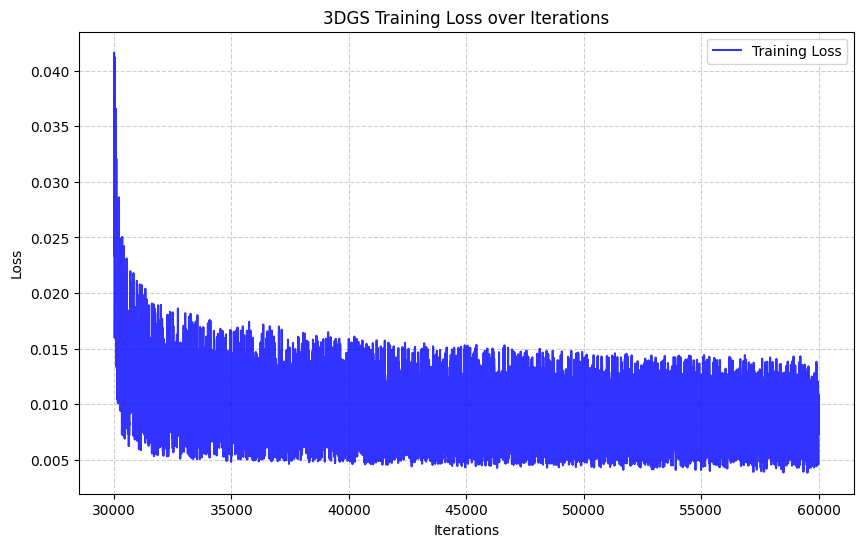

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# Path to the 3DGS output directory where you saved the model
log_dir = "/content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS"

# Find the TensorBoard events file
event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents*"))

if not event_files:
    print(f"No TensorBoard event files found in {log_dir}.")
else:
    print(f"Found event file: {event_files[0]}")
    # Load the event accumulator
    ea = event_accumulator.EventAccumulator(event_files[0])
    ea.Reload()

    # Check available tags (metrics)
    tags = ea.Tags()['scalars']

    # Usually 3DGS logs it under 'train_loss'
    loss_tag = 'train_loss' if 'train_loss' in tags else (tags[0] if tags else None)

    if loss_tag:
        # Extract steps and loss values
        loss_events = ea.Scalars(loss_tag)
        steps = [e.step for e in loss_events]
        losses = [e.value for e in loss_events]

        # Plot the loss curve
        plt.figure(figsize=(10, 6))
        plt.plot(steps, losses, label="Training Loss", color='b', alpha=0.8)
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.title("3DGS Training Loss over Iterations")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("Could not find any loss metrics in the TensorBoard logs.")

In [ ]:
# --- RESUME 3DGS LATER ---
# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

# If the colab disconnects or you want to train further (e.g., to 40k), you can run:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on \
    --start_checkpoint /content/gaussian-splatting/output/vadim_try_on/chkpnt30000.pth \
    --checkpoint_iterations 100000 \
    --iterations 100000

Optimizing /content/gaussian-splatting/output/vadim_try_on
Output folder: /content/gaussian-splatting/output/vadim_try_on [20/05 22:18:17]
Reading camera 56/56 [20/05 22:18:18]
Loading Training Cameras [20/05 22:18:18]
Loading Test Cameras [20/05 22:18:18]
Number of points at initialisation :  3950 [20/05 22:18:18]
Training progress: 100% 70000/70000 [12:15<00:00, 95.19it/s, Loss=0.0163329]

[ITER 100000] Saving Gaussians [20/05 22:30:35]

[ITER 100000] Saving Checkpoint [20/05 22:30:36]

Training complete. [20/05 22:30:36]


In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vadim_try_on /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_2_phase_splat_v2

# Freeze Pip versions

In [ ]:
!pip freeze > /content/requirements_locked.txt
print("Saved locked requirements to /content/requirements_locked.txt")
!head -n 10 /content/requirements_locked.txt